In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from typing import Tuple, List
import io
import re
import numpy as np
import requests
import time

# Load Datasets

In [3]:
from typing import Tuple, List
from __future__ import annotations
import io
import re
import numpy as np
import requests
import time

def days_and_hours_since_2020(minutes_since_epoch) -> Tuple[int, int]:
    # Decode minutes_since_epoch → (year, month, day, hour)
    total_days, rem = divmod(int(minutes_since_epoch), 24 * 60)
    hour = rem // 60

    def _days_since_year0(y, m, d):
        days = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
        if (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0):
            days[2] = 29
        return y * 365 + y // 4 - y // 100 + y // 400 + sum(days[1:m]) + (d - 1)

    abs_days = total_days + _days_since_year0(1970, 1, 1)

    year = int(abs_days / 365.2425)
    while _days_since_year0(year + 1, 1, 1) <= abs_days:
        year += 1
    while _days_since_year0(year, 1, 1) > abs_days:
        year -= 1

    month = 1
    while month < 12 and _days_since_year0(year, month + 1, 1) <= abs_days:
        month += 1

    day = abs_days - _days_since_year0(year, month, 1) + 1

    # Day-of-year in 365-day scheme (Feb always = 28 days, Feb 29 excluded)
    days_per_month = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    doy = sum(days_per_month[1:month]) + (day - 1)   # 0-indexed

    day_index = (year - 2020) * 365 + doy
    return (day_index, hour)

# Placeholder for all data
class MeteoDataChunked:
    def _encode_days_and_hours(self):
        self.h_cos = np.zeros(len(self.timestamps))
        self.h_sin = np.zeros(len(self.timestamps))
        self.d_cos = np.zeros(len(self.timestamps))
        self.d_sin = np.zeros(len(self.timestamps))
        for i, t in enumerate(self.timestamps):
            d, h = days_and_hours_since_2020(t)
            self.h_cos[i] = np.cos(h/24 * 2 * np.pi) * np.sqrt(2)
            self.h_sin[i] = np.sin(h/24 * 2 * np.pi) * np.sqrt(2)
            self.d_cos[i] = np.cos(d/365 * 2 * np.pi) * np.sqrt(2)
            self.d_sin[i] = np.sin(d/365 * 2 * np.pi) * np.sqrt(2)

    def __init__(self, name, timestamps: np.ndarray, global_rad: np.ndarray,
                temp: np.ndarray, rel_hum: np.ndarray, pressure: np.ndarray, wind_speed: np.ndarray, means=None, sigmas=None):
        self.name       = name
        self.timestamps = timestamps
        if means is None or sigmas is None:
            self.global_rad = global_rad
            self.temp       = temp
            self.pressure   = pressure
            self.rel_hum    = rel_hum
            self.wind_speed = wind_speed
        else:
            self.global_rad = (global_rad - means[0])/sigmas[0]
            self.temp       = (temp - means[1])/sigmas[1]
            self.pressure   = (pressure - means[2])/sigmas[2]
            self.rel_hum    = (rel_hum - means[3])/sigmas[3]
            self.wind_speed = wind_speed # TODO
        self._encode_days_and_hours()

    @classmethod
    def from_meteodata(cls, md: MeteoDataChunked):
        return MeteoDataChunked(md.name, md.timestamps, md.global_rad, md.temp, md.rel_hum,
                                md.pressure, md.wind_speed, md.means, md.sigmas)

    def __repr__(self):
        start = days_and_hours_since_2020(self.timestamps[0])
        end   = days_and_hours_since_2020(self.timestamps[-1])
        ret = f"Timestamps since {start[0]} to {end[0]}."
        return ret

    def __len__(self):
        return len(self.timestamps)

    def cut(self, start_idx: int, end_idx: int) -> MeteoDataChunked:
        if start_idx >= end_idx:
            return None
        new = MeteoDataChunked(
            self.name,
            self.timestamps[start_idx:end_idx],
            self.global_rad[start_idx:end_idx],
            self.temp[start_idx:end_idx],
            self.rel_hum[start_idx:end_idx],
            self.pressure[start_idx:end_idx],
            self.wind_speed[start_idx:end_idx],
        )
        return new

    @staticmethod
    def stats_from_more_chunks(chunks: List['MeteoDataChunked']) -> Tuple[np.ndarray, np.ndarray]:
        new = MeteoDataChunked(
            "NORMALIZED",
            np.concatenate([c.timestamps  for c in chunks]),
            np.concatenate([c.global_rad  for c in chunks]),
            np.concatenate([c.temp        for c in chunks]),
            np.concatenate([c.rel_hum     for c in chunks]),
            np.concatenate([c.pressure    for c in chunks]),
            np.concatenate([c.wind_speed  for c in chunks]),
        )
        mean = np.array([
            new.global_rad.mean(),
            new.temp.mean(),
            new.pressure.mean(),
            new.rel_hum.mean(),
        ])
        std = np.array([
            new.global_rad.std(),
            new.temp.std(),
            new.pressure.std(),
            new.rel_hum.std(),
        ])
        return mean, std
        

In [5]:
# Start with the Openmeteo data, then load the BSRN data.
NGROK_URL = "https://curtly-salvageable-clementina.ngrok-free.dev"

# Connect to the ngrok URL and retrieve data from dataset-openmeteo/saved
def load_openmeteo_data() -> List[MeteoDataChunked]:
    ret = []
    cities = ["Dunakezsi", "Pecel", "Szigetszentmiklos", "Vecses"]
    for c in cities:
        response = requests.get(f"{NGROK_URL}/dataset-openmeteo/saved/{c}.npz")
        data = np.load(io.BytesIO(response.content))
        ret.append(MeteoDataChunked(c, data["timestamps"],    data["global_tilted_irradiance"],
                                    data["temperature_2m"],   data["relative_humidity_2m"],
                                    data["surface_pressure"], data["wind_speed_10m"]))
    return ret

def load_bsrn_data() -> List[MeteoDataChunked]:
    base_url = f"{NGROK_URL}/dataset-bsrn/saved"

    def list_files() -> List[str]:
        html = requests.get(base_url).text
        return re.findall(r'href="([^"/?][^"]*)"', html)

    ret = []
    files = list_files()
    for f in files:
        if f == "dates.txt":
            continue
        response = requests.get(f"{base_url}/{f}")
        data = np.load(io.BytesIO(response.content))
        # Get the chunk number rn
        number = int((f[5:])[0:-4])
        # Get the budapest wind speed
        response = requests.get(f"{NGROK_URL}/dataset-openmeteo/saved/Budapest{number}.npz")
        data_openmeteo = np.load(io.BytesIO(response.content))
        wind_speed = data_openmeteo["wind_speed_10m"]

        ret.append(MeteoDataChunked("BSRN", data["timestamps"],  data["global_rad"],
                                            data["temperature"], data["humidity"],
                                            data["pressure"],    wind_speed))
        # Stupid ngrok max reqs hack
        time.sleep(1)
    
    return ret

openmeteo_chunks = load_openmeteo_data()
bsrn_chunks      = load_bsrn_data()

# Data Loaded, create PyTorch Dataset

In [150]:
# The sliding window length
CONSECUTIVE_HOURS       = 3 * 24 # 3 days
CONSECUTIVE_HOURS_AFTER = 2 * 24 # 2 days
TEST_FRACTION           = 0.20

# Create train and testing data. Merge them and compute mean and stds.
# First, process the openmeteo data. BSRN will be used for tinetuning.

def create_train_and_test_chunks(chunks, batch_size: int = 32):
    """
    TODO
    """
    n = len(chunks)
    TRAIN_TO_TEST = int(1/TEST_FRACTION)

    all_train_data,   all_train_labels = [], []
    all_test_data,    all_test_labels  = [], []

    train_data = []
    test_data  = []

    # Perform cross validation on more chunks. From this, compute train statistics (mean, std).
    for i, c in enumerate(chunks):
        L = len(c.timestamps)
        if len(c.timestamps)/TRAIN_TO_TEST >= (CONSECUTIVE_HOURS + CONSECUTIVE_HOURS_AFTER):
            # Slice the data first.
            test_start = int((1.0 - ((i % TRAIN_TO_TEST) + 1) * TEST_FRACTION) * L)
            test_end   = int((1.0 -  (i % TRAIN_TO_TEST)      * TEST_FRACTION) * L)
            # Slice before
            before = c.cut(0, test_start)
            if before is not None:
                train_data.append(c.cut(0, test_start))
            # Slide test data
            between = c.cut(test_start, test_end)
            if between is not None:
                test_data.append(c.cut(test_start, test_end))
            # Slide train data after
            after = c.cut(test_end, L)
            if after is not None:
                train_data.append(after)
        else:
            # The testing data would be too small. Just append everything to training
            train_data.append(c)

    meteo_train_means, meteo_train_sigmas = MeteoDataChunked.stats_from_more_chunks(train_data)
    print(f"Training data computed means: {meteo_train_means}, sigmas: {meteo_train_sigmas}")
    
    # Perform normalization
    train_data_normalized = []; test_data_normalized = []
    for c in train_data:
        c.means  = meteo_train_means
        c.sigmas = meteo_train_sigmas
        train_data_normalized.append(MeteoDataChunked.from_meteodata(c))
    for c in test_data:
        c.means  = meteo_train_means
        c.sigmas = meteo_train_sigmas
        test_data_normalized.append(MeteoDataChunked.from_meteodata(c))

    return train_data_normalized, test_data_normalized, meteo_train_means, meteo_train_sigmas

openmeteo_train_chunks, openmeteo_test_chunks, openmeteo_mu, openmeteo_sigma = create_train_and_test_chunks(openmeteo_chunks)
bsrn_train_chunks, bsrn_test_chunks, _, _ = create_train_and_test_chunks(bsrn_chunks)


Training data computed means: [ 181.51119527   11.98794258 1001.99537615   71.43260004], sigmas: [271.15680132   9.07571069   8.22160975  19.33177785]
Training data computed means: [ 145.07526277   11.77084865 1000.40177776   69.62959326], sigmas: [230.84684451   9.01666915   7.94663881  21.21463034]


In [303]:
# Test the data is correct, actually

#plt.plot(bsrn_train_chunks[0].timestamps)
#plt.show()

In [151]:
WEATHER_VARIABLES = 3

# Now, create sliding windows from such data and data PyTorch data loaders
def create_dataloader(chunks_normalized: List[MeteoDataChunked], cons_hours, cons_hours_after, batch_size=32, shuffle=True):
    """
    Create sliding windows from every chunk from chunks_normalized.
    Returns (data: (N, cons_hours, 8), labels: (N, cons_hours)),
    where N is the number of sliding windows created
    """
    N_FEATURES = 8       # cos(h), sin(h), cos(d), sin(d), GTI(i-1), temp, pressure, hum

    N = 0
    for c in chunks_normalized:
        N += len(c.timestamps) - (cons_hours + cons_hours_after)

    data_prior = np.zeros((N, cons_hours, N_FEATURES), dtype=np.float32)                           # Encoder input data
    teach_enf  = np.zeros((N, cons_hours_after, N_FEATURES - WEATHER_VARIABLES), dtype=np.float32) # Inputs for the decoder input for teacher enforcing
    labels_exp = np.zeros((N, cons_hours_after), dtype=np.float32)                                 # Expected labels for the decoder output
    timestamps = np.zeros((N, cons_hours), dtype=np.float32)                                       # Timestamp marks. Not needed, only for later use.

    i = 0
    for c in chunks_normalized:
        for j in range(1, len(c.timestamps) - cons_hours - cons_hours_after + 1):
            data_prior[i, :, :] = np.vstack([
                c.h_cos[j:j+cons_hours],
                c.h_sin[j:j+cons_hours],
                c.d_cos[j:j+cons_hours],
                c.d_sin[j:j+cons_hours],
                c.global_rad[j-1:j-1+cons_hours],
                c.temp[j:j+cons_hours],
                c.pressure[j:j+cons_hours],
                c.rel_hum[j:j+cons_hours],
            ]).T
            teach_enf[i, :, :]  = np.vstack([
                c.h_cos[j+cons_hours:j+cons_hours+cons_hours_after],
                c.h_sin[j+cons_hours:j+cons_hours+cons_hours_after],
                c.d_cos[j+cons_hours:j+cons_hours+cons_hours_after],
                c.d_sin[j+cons_hours:j+cons_hours+cons_hours_after],
                c.global_rad[j+cons_hours-1:j+cons_hours+cons_hours_after-1]]).T
            labels_exp[i, :] = c.global_rad[j+cons_hours:j+cons_hours+cons_hours_after]
            timestamps[i, :] = c.timestamps[j:j+cons_hours]
            i += 1

    ds = TensorDataset(torch.from_numpy(data_prior), torch.from_numpy(teach_enf), torch.from_numpy(labels_exp),
                       torch.from_numpy(timestamps))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return loader

print("Creating dataloaders")
openmeteo_train_loader = create_dataloader(openmeteo_train_chunks, CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER)
print("Openmeteo train loader created!")
openmeteo_test_loader  = create_dataloader(openmeteo_test_chunks,  CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER, shuffle=False)
print("Openmeteo test loader created!")
bsrn_train_loader      = create_dataloader(bsrn_train_chunks, CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER)
print("BSRN train loader created!")
bsrn_test_loader       = create_dataloader(bsrn_test_chunks, CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER, shuffle=False)
print("BSRN test loader created!")

Creating dataloaders
Openmeteo train loader created!
Openmeteo test loader created!
BSRN train loader created!
BSRN test loader created!


# GRU PyTorch

In [ ]:
N_FEATURES = 8
DROPOUT = 0.2
OUTPUT_SIZE = 1 # GTI only
HIDDEN_SIZE = 128
LEARNING_RATE = 5e-6
EPOCHS = 15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device is", DEVICE)
if DEVICE.type != "cuda":
    raise Exception("You need to use cuda or you will bore yourself to death.")

class SolarSeq2SeqGRU(nn.Module):
    def __init__(self):
        # The encoder inputs are: time (4 scalars), GTI(i-1), weather variables.
        # The decoder inputs are: time (5 scalars), GTI(i-1).
        super().__init__()
        self.encoder = nn.GRU(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE, batch_first=True)
        self.decoder = nn.GRU(input_size=5, hidden_size=HIDDEN_SIZE, batch_first=True)
        self.fc      = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE)
        
    def forward(self, prior, teacher_seq, target_len=CONSECUTIVE_HOURS_AFTER):
        all_preds = []
        # Training mode - teacher forcing.
        if self.training and teacher_seq is not None:
            _, hidden      = self.encoder(prior)
            decoder_out, _ = self.decoder(teacher_seq, hidden)
            preds = self.fc(decoder_out)
            return preds.squeeze(-1)
        # Evaluation mode
        else:
            _, hidden = self.encoder(prior)
            # We don't need to teacher forcing GTI data, but we need
            # the timestamps. The first timestamp can be directly taken from teacher_seq.
            # Don't forget to keep the batch_size.
            curr_input = teacher_seq[:, 0:1, 0:5]
            for i in range(target_len):
                out, hidden = self.decoder(curr_input, hidden)
                pred = self.fc(out)
                all_preds.append(pred)
                if i != target_len-1:
                    curr_input = torch.cat([teacher_seq[:, i+1:i+2, 0:4], pred], dim=2)
            return torch.cat(all_preds, dim=1).squeeze(-1)

def seq2seq_train(model: nn.Module,
                  loss_fn: nn.modules.loss._Loss,
                  optimizer: torch.optim.Optimizer,
                  train_loader: DataLoader,
                  epoch: int=0) -> List[float]:
    n_iters = len(train_loader)
    model.train()
    train_loss = [0] * n_iters
    for batch_idx, (encoder_in, decoder_in, labels, _) in enumerate(train_loader):
        encoder_in, decoder_in, labels = encoder_in.to(DEVICE), decoder_in.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        output = model(encoder_in, decoder_in)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        if batch_idx % max(1, n_iters // 8) == 0:
            print(f'Epoch {epoch}: [{batch_idx*len(encoder_in)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

        train_loss[batch_idx] = loss.item()

    return train_loss


def seq2seq_test(model: nn.Module,
                 loss_fn: nn.modules.loss._Loss,
                 test_loader: DataLoader) -> float:
    test_loss = 0
    
    model.eval()
    with torch.no_grad():
        for encoder_in, decoder_in, labels, _ in test_loader:
            encoder_in, decoder_in, labels = encoder_in.to(DEVICE), decoder_in.to(DEVICE), labels.to(DEVICE)
            output = model(encoder_in, decoder_in)
            test_loss += loss_fn(output, labels).item()

    return test_loss

model = SolarSeq2SeqGRU()
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss()
losses = []

for epoch in range(EPOCHS):
    l = seq2seq_train(model, criterion, optimizer, openmeteo_train_loader, epoch)
    losses.append(l)
    loss_test_total = seq2seq_test(model, criterion, openmeteo_test_loader)
    print(f"Finished epoch {epoch}. Loss = {loss_test_total}")


Available device is cuda
Epoch 0: [0/167351] Loss: 0.392
Epoch 0: [20896/167351] Loss: 0.444
Epoch 0: [41792/167351] Loss: 0.387
Epoch 0: [62688/167351] Loss: 0.348
Epoch 0: [83584/167351] Loss: 0.282
Epoch 0: [104480/167351] Loss: 0.287
Epoch 0: [125376/167351] Loss: 0.242
Epoch 0: [146272/167351] Loss: 0.226
Epoch 0: [167168/167351] Loss: 0.191
Finished epoch 0. Loss = 295.93333926424384
Epoch 1: [0/167351] Loss: 0.194
Epoch 1: [20896/167351] Loss: 0.167
Epoch 1: [41792/167351] Loss: 0.154
Epoch 1: [62688/167351] Loss: 0.124
Epoch 1: [83584/167351] Loss: 0.126
Epoch 1: [104480/167351] Loss: 0.104
Epoch 1: [125376/167351] Loss: 0.097
Epoch 1: [146272/167351] Loss: 0.105
Epoch 1: [167168/167351] Loss: 0.091
Finished epoch 1. Loss = 155.08655726909637
Epoch 2: [0/167351] Loss: 0.095
Epoch 2: [20896/167351] Loss: 0.084
Epoch 2: [41792/167351] Loss: 0.079
Epoch 2: [62688/167351] Loss: 0.079
Epoch 2: [83584/167351] Loss: 0.076
Epoch 2: [104480/167351] Loss: 0.069
Epoch 2: [125376/167351] L

torch.Size([1, 48, 5])
torch.Size([1, 72, 8])


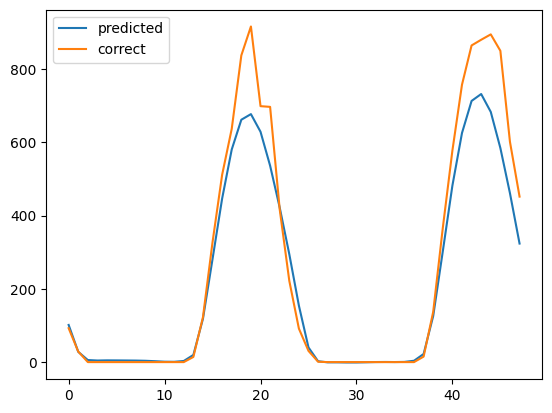

In [149]:
import random

def seq2seq_inference(
    model: nn.Module,
    prior_data: torch.Tensor,
    timestamps: torch.Tensor,
    minute_step=60) -> np.ndarray:
    """
    Perform inference using the seq2seq gru model.
    Automatically computes timestamps for the prediction, based on the last data from prior.
    The default minute step is 60, but can be changed if the data is different.
    Arguments:
        prior:       prior knowledge, the same format used in training, testing.
        minute_step: minute step
    """
    tslast = timestamps[-1].numpy()
    d_cos  = np.zeros(CONSECUTIVE_HOURS_AFTER, dtype=np.float32)
    d_sin  = np.zeros(CONSECUTIVE_HOURS_AFTER, dtype=np.float32)
    h_cos  = np.zeros(CONSECUTIVE_HOURS_AFTER, dtype=np.float32)
    h_sin  = np.zeros(CONSECUTIVE_HOURS_AFTER, dtype=np.float32)
    # Dummy GTI. Will be ignored in the inference
    dummy  = np.zeros(CONSECUTIVE_HOURS_AFTER, dtype=np.float32)
    for i in range(CONSECUTIVE_HOURS_AFTER):
        ts = tslast + (i + 1) * minute_step
        d, h = days_and_hours_since_2020(ts)
        d_cos[i] = np.cos(d/365 * 2 * np.pi) * np.sqrt(2)
        d_sin[i] = np.sin(d/365 * 2 * np.pi) * np.sqrt(2)
        h_cos[i] = np.cos(h/24 * 2 * np.pi) * np.sqrt(2)
        h_sin[i] = np.sin(h/24 * 2 * np.pi) * np.sqrt(2)

    # Now we have timestamps ready, construct the decoder inputs.
    # Note: GTI is dummy, but we keep to keep the dimensions correct, just to be sure.
    decoder_in = torch.from_numpy(np.vstack([h_cos, h_sin, d_cos, d_sin, dummy]).T).unsqueeze(0)
    decoder_in = decoder_in.to(DEVICE)
    prior_data = prior_data.unsqueeze(0)
    prior_data = prior_data.to(DEVICE)
    print(decoder_in.shape)
    print(prior_data.shape)
    model.eval()
    return model(prior_data, decoder_in).detach().cpu().numpy()

mu_gti = 181.51119527
sigma_gti = 271.15680132

# Get random data from test loader.
encoder_in, _, correct_labels, timestamps = random.choice(list(iter(openmeteo_test_loader)))
correct_labels = correct_labels[0].numpy() * sigma_gti + mu_gti
encoder_in = encoder_in[0]
timestamps = timestamps[0]
predictions = seq2seq_inference(model, encoder_in, timestamps) * sigma_gti + mu_gti

plt.plot(predictions[0], label="predicted")
plt.plot(correct_labels, label="correct")
plt.legend()